# 과제 - PyTorch로 mini GPT 구현

이 노트북은 과제 안내서의 구현 순서를 그대로 따릅니다.

1. 환경설정
2. NSMC 데이터 준비
3. BPE 토크나이저
4. GPTDataset / InputEmbedding
5. MultiHeadAttention
6. GPTModel
7. 사전 학습 유틸리티
8. 감성 분류 미세 조정

각 단계의 `src/` TODO를 구현한 뒤, 바로 아래 pytest 셀로 해당 단계만 확인하세요.

## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다.
로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.

In [1]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(input("GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): "))
    token = getpass("GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ").strip()
    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")

    os.chdir(repo_dir)
else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))
print(f"Repo: {repo_dir}")

Repo: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT


In [2]:
# 단계별 테스트 실행 helper
import subprocess
import sys


def run_pytest(target: str):
    cmd = [sys.executable, "-m", "pytest", target, "-v"]
    print("실행 명령:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(repo_dir), text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        print("\n아직 통과하지 못한 테스트가 있습니다. 해당 단계의 TODO를 먼저 구현하세요.")
    else:
        print("\n선택한 테스트를 통과했습니다.")
    return result.returncode

## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다.
`download_data.py`는 원본 TSV를 내려받고, 사전 학습용 텍스트와 감성 분류용 JSONL을 만듭니다.

In [3]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)

이미 존재합니다: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/data/ratings_train.txt
이미 존재합니다: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/data/ratings_test.txt
사전 학습 train 텍스트: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/data/nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/data/nsmc_lm_val.txt (120,560자)
감성 분류 train: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/data/nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/data/nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/data/nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/data/nsmc_lm_train.txt
LM val exists: True /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/data/nsmc_lm_val.txt


In [4]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. Step 1 - BPE 토크나이저

구현 파일: `src/bpe.py`

먼저 `pytest tests/test_bpe.py -v`를 통과시키세요. 한국어를 안전하게 다루기 위해 UTF-8 byte-level BPE로 구현해야 합니다.

In [5]:
run_pytest("tests/test_bpe.py")

실행 명령: /Users/j/miniforge3/envs/gpt-lab/bin/python -m pytest tests/test_bpe.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/j/miniforge3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT
collecting ... collected 6 items

tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 16%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 33%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 50%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 66%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 83%]
tests/test_bpe.py::TestBPETrain::test_train_increases_vocab PASSED       [100%]

============================== 6 passed in 0.01s ===============================


선택한 테스트를 통과했습니다.


0

In [6]:
# BPE 구현 후 작은 말뭉치로 인코딩/디코딩 복원을 확인합니다.
try:
    from bpe import BPETokenizer

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    sample = "이 영화는 정말 좋았다! English 123"
    ids = tokenizer.encode(sample, add_bos_eos=True)
    print(ids[:20])
    print(tokenizer.decode(ids))
except NotImplementedError as e:
    print("BPE TODO 미구현:", e)

[2, 265, 260, 290, 268, 260, 164, 153, 274, 148, 260, 166, 143, 281, 156, 270, 37, 36, 73, 114]
이 영화는 정말 좋았다! English 123


## 4. Step 2 - GPTDataset / InputEmbedding

구현 파일: `src/dataset.py`, `src/embeddings.py`

BPE가 통과한 뒤 데이터셋과 입력 임베딩을 구현합니다.

In [7]:
run_pytest("tests/test_dataset.py")

실행 명령: /Users/j/miniforge3/envs/gpt-lab/bin/python -m pytest tests/test_dataset.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/j/miniforge3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT
collecting ... collected 4 items

tests/test_dataset.py::TestGPTDataset::test_dataset_length PASSED        [ 25%]
tests/test_dataset.py::TestGPTDataset::test_dataset_getitem_shape PASSED [ 50%]
tests/test_dataset.py::TestCreateDataloader::test_dataloader_batch_shape PASSED [ 75%]
tests/test_dataset.py::TestInputEmbedding::test_input_embedding_shape PASSED [100%]

============================== 4 passed in 1.00s ===============================


선택한 테스트를 통과했습니다.


0

In [8]:
try:
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from embeddings import InputEmbedding

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    emb = InputEmbedding(vocab_size=300, emb_dim=32, context_length=32, drop_rate=0.0)
    out = emb(inp)
    print(inp.shape, tgt.shape, out.shape)
except NotImplementedError as e:
    print("Dataset/Embedding TODO 미구현:", e)

torch.Size([2, 32]) torch.Size([2, 32]) torch.Size([2, 32, 32])


## 5. Step 3 - MultiHeadAttention

구현 파일: `src/attention.py`

Q/K/V shape, head 분리, causal mask를 차례로 확인하세요.

In [9]:
run_pytest("tests/test_attention.py")

실행 명령: /Users/j/miniforge3/envs/gpt-lab/bin/python -m pytest tests/test_attention.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/j/miniforge3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT
collecting ... collected 2 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [ 50%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [100%]

============================== 2 passed in 0.46s ===============================


선택한 테스트를 통과했습니다.


0

## 6. Step 4 - GPTModel

구현 파일: `src/model.py`

LayerNorm, GELU, FeedForward, TransformerBlock, GPTModel, `generate_text_simple` 순서로 구현합니다.

In [10]:
run_pytest("tests/test_model.py")

실행 명령: /Users/j/miniforge3/envs/gpt-lab/bin/python -m pytest tests/test_model.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/j/miniforge3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT
collecting ... collected 7 items

tests/test_model.py::TestLayerNorm::test_layernorm_shape PASSED          [ 14%]
tests/test_model.py::TestGELU::test_gelu_shape PASSED                    [ 28%]
tests/test_model.py::TestFeedForward::test_feedforward_shape PASSED      [ 42%]
tests/test_model.py::TestTransformerBlock::test_transformer_block_shape PASSED [ 57%]
tests/test_model.py::TestGPTModel::test_gpt_forward_shape PASSED         [ 71%]
tests/test_model.py::TestGPTModel::test_gpt_forward_with_targets_returns_loss PASSED [ 85%]
tests/test_model.py::TestGenerateTextSimple::test_generate_text_simple_shape PASSED [100%]

==================

0

In [11]:
try:
    import torch
    from model import GPTModel

    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    x = torch.randint(0, config["vocab_size"], (2, 16))
    logits = model(x)
    print(logits.shape)
except NotImplementedError as e:
    print("Model TODO 미구현:", e)

torch.Size([2, 16, 300])


## 7. Step 5 - 사전 학습 유틸리티

구현 파일: `src/train.py`

loss 계산, checkpoint 저장/로드, temperature/top-k 생성, `train_model`을 구현합니다.

In [12]:
run_pytest("tests/test_train.py")

실행 명령: /Users/j/miniforge3/envs/gpt-lab/bin/python -m pytest tests/test_train.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/j/miniforge3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT
collecting ... collected 5 items

tests/test_train.py::TestCalcLossBatch::test_calc_loss_batch_returns_scalar PASSED [ 20%]
tests/test_train.py::TestCalcLossLoader::test_calc_loss_loader_returns_float PASSED [ 40%]
tests/test_train.py::TestCheckpoint::test_save_load_checkpoint_restores_epoch_and_step PASSED [ 60%]
tests/test_train.py::TestGenerate::test_generate_shape PASSED            [ 80%]
tests/test_train.py::TestPlotLosses::test_plot_losses_callable PASSED    [100%]

=============================== warnings summary ===============================
tests/test_train.py::TestPlotLosses::test_plot_losses_callable
  /Users/j/Desktop/Ju

0

In [ ]:
# 모든 앞 단계가 구현된 뒤 한 배치 smoke test를 실행합니다.
try:
    import torch
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from model import GPTModel
    from train import calc_loss_batch

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    loss = calc_loss_batch(inp, tgt, model, torch.device("cpu"))
    loss.backward()
    print("smoke loss:", loss.item())
except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)

saved tokenizer load: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/outputs/pretrain_run/tokenizer.json
checkpoint load: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/outputs/pretrain_run/pretrain_final_checkpoint.pt
continue from epoch=6, global_step=1182, old_rows=17
step 1200: train_loss=5.8280, val_loss=5.9426, val_acc=0.0747, val_ppl=380.94
step 1300: train_loss=5.7901, val_loss=5.8671, val_acc=0.0771, val_ppl=353.22
epoch 6: train_loss=5.7689, val_loss=5.8132
이 영화는 너무 하니
저도가야지원으로 쌍랬다!!
아이트맨이트만
감동을 잃나와 조연은 왜이 아깝다
여운 느낌도 좋고 이것같은걸까? 아마이 아니라
step 1400: train_loss=5.6349, val_loss=5.8059, val_acc=0.0798, val_ppl=332.27
step 1500: train_loss=5.6278, val_loss=5.7568, val_acc=0.0815, val_ppl=316.34
epoch 7: train_loss=5.6174, val_loss=5.7237
이 영화는 나타가없을 자유스크라기덕나와서 볼때는 건지 ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ
내가 평점 이래요한 이야기를 안하구가면 그걸 봤는데 더 안나서 나부하셨을까..
step 1600: train_loss=5.5076, val_loss=5.7160, val_acc=0.0822, val_ppl=303.69
step 1700: train_loss=5.5100, val_loss=5.6860, val_acc=0.08

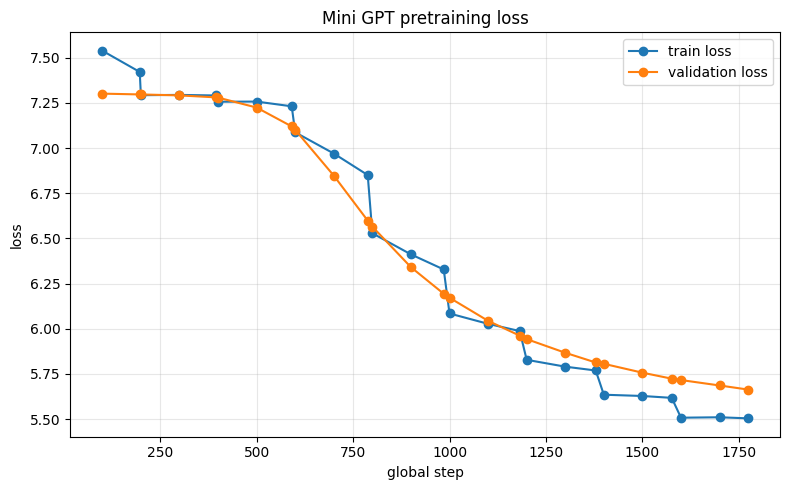

이 영화는 다만해 보겠다...
진짜 재미없는데... 영화.. 너무 좋았음
정말 잘 만들까요? 정말 재밋게 만든 영화~
아..
영화의 뺀..아~~
캅시도안되는 아닌 영화다만은,이 좀 재미있게 안나니깐..감동적이다이긴한데, 정말 감동은 무슨 여성우들아라라스테로맨
metrics: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/outputs/pretrain_run/pretrain_metrics.jsonl
final json: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/outputs/pretrain_run/pretrain_final_result.json
plot: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/outputs/pretrain_run/pretrain_loss_curve.png
tokenizer: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/outputs/pretrain_run/tokenizer.json
checkpoint: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT/outputs/pretrain_run/pretrain_final_checkpoint.pt


In [15]:
# 실제 mini GPT 사전학습 실행 + 중간/최종 결과 저장 셀입니다.
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from bpe import BPETokenizer
from dataset import create_dataloader
from model import GPTModel
from train import generate, train_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
output_dir = repo_dir / "outputs" / "pretrain_run"
output_dir.mkdir(parents=True, exist_ok=True)

metrics_path = output_dir / "pretrain_metrics.jsonl"
final_json_path = output_dir / "pretrain_final_result.json"
plot_path = output_dir / "pretrain_loss_curve.png"
tokenizer_path = output_dir / "tokenizer.json"
checkpoint_path = output_dir / "pretrain_final_checkpoint.pt"

train_text = corpus[:1500000]
val_text = val_corpus[:200000] if val_corpus else corpus[1500000:1700000]

tokenizer = BPETokenizer(vocab_size=3000)
if tokenizer_path.exists():
    print("saved tokenizer load:", tokenizer_path)
    tokenizer.load(tokenizer_path)
else:
    print("new tokenizer train:", tokenizer_path)
    tokenizer.train(train_text)
    tokenizer.save(tokenizer_path)

train_token_ids = tokenizer.encode(train_text)
val_token_ids = tokenizer.encode(val_text) if val_text else []

train_loader = create_dataloader(
    train_token_ids,
    context_length=128,
    batch_size=32,
    shuffle=True,
)
val_loader = None
if len(val_token_ids) > 129:
    val_loader = create_dataloader(
        val_token_ids,
        context_length=128,
        batch_size=32,
        shuffle=False,
    )

config = {
    "vocab_size": 3000,
    "context_length": 128,
    "emb_dim": 128,
    "n_heads": 8,
    "n_layers": 4,
    "drop_rate": 0.0,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

old_history = []
start_epoch = 0
global_step = 0
if checkpoint_path.exists():
    print("checkpoint load:", checkpoint_path)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    checkpoint_config = checkpoint.get("config", {})
    shape_keys = ["vocab_size", "context_length", "emb_dim", "n_heads", "n_layers", "qkv_bias"]
    mismatches = [key for key in shape_keys if checkpoint_config.get(key) != config.get(key)]
    if mismatches:
        raise ValueError(f"checkpoint config mismatch: {mismatches}. 새 설정이면 checkpoint_path를 바꾸거나 기존 파일을 옮기세요.")
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    old_history = checkpoint.get("history", [])
    if old_history:
        last_row = old_history[-1]
        start_epoch = int(last_row.get("epoch", -1)) + 1
        global_step = int(last_row.get("global_step", 0))
    print(f"continue from epoch={start_epoch}, global_step={global_step}, old_rows={len(old_history)}")
else:
    print("new checkpoint train:", checkpoint_path)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=None,
    optimizer=optimizer,
    device=device,
    num_epochs=3,
    eval_freq=100,
    eval_iter=20,
    start_context="이 영화는",
    tokenizer=tokenizer,
    metrics_path=metrics_path,
    return_history=True,
    start_epoch=start_epoch,
    global_step=global_step,
)

rows = old_history + history["history"]
steps = [row["global_step"] for row in rows]
train_losses = [row.get("train_loss") for row in rows]
val_points = [(row["global_step"], row["val_loss"]) for row in rows if "val_loss" in row]

plt.figure(figsize=(8, 5))
plt.plot(steps, train_losses, marker="o", label="train loss")
if val_points:
    val_steps, val_losses = zip(*val_points)
    plt.plot(val_steps, val_losses, marker="o", label="validation loss")
plt.xlabel("global step")
plt.ylabel("loss")
plt.title("Mini GPT pretraining loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.show()

start_context = "이 영화는"
encoded = tokenizer.encode(start_context, add_bos_eos=False)
idx = torch.tensor(encoded, dtype=torch.long, device=device).unsqueeze(0)
generated_ids = generate(
    model=model,
    idx=idx,
    max_new_tokens=80,
    context_size=config["context_length"],
    temperature=0.8,
    top_k=40,
    eos_id=tokenizer.get_eos_id(),
)
generated_text = tokenizer.decode(generated_ids[0].tolist(), skip_special=True)
print(generated_text)

final_result = {
    "config": config,
    "device": str(device),
    "train_chars": len(train_text),
    "val_chars": len(val_text),
    "train_tokens": len(train_token_ids),
    "val_tokens": len(val_token_ids),
    "continued_epochs": 3,
    "start_epoch": start_epoch,
    "global_step": rows[-1].get("global_step", global_step) if rows else global_step,
    "final_metrics": rows[-1] if rows else {},
    "generated_text": generated_text,
    "artifacts": {
        "metrics_jsonl": str(metrics_path),
        "final_json": str(final_json_path),
        "loss_plot_png": str(plot_path),
        "tokenizer_json": str(tokenizer_path),
        "checkpoint_pt": str(checkpoint_path),
    },
}
metrics_path.write_text("".join(json.dumps(row, ensure_ascii=False) + "\n" for row in rows), encoding="utf-8")
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": config,
        "history": rows,
        "final_result": final_result,
    },
    checkpoint_path,
)
final_json_path.write_text(json.dumps(final_result, ensure_ascii=False, indent=2), encoding="utf-8")

print("metrics:", metrics_path)
print("final json:", final_json_path)
print("plot:", plot_path)
print("tokenizer:", tokenizer_path)
print("checkpoint:", checkpoint_path)

## 8. Step 6 - 감성 분류 미세 조정

구현 파일: `src/finetune.py`

NSMC JSONL/TSV를 읽어 분류 Dataset을 만들고, GPT backbone 위에 classification head를 붙입니다.

In [ ]:
run_pytest("tests/test_finetune.py")

실행 명령: /Users/j/miniforge3/envs/gpt-lab/bin/python -m pytest tests/test_finetune.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/j/miniforge3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT
collecting ... collected 4 items

tests/test_finetune.py::TestMakeSentimentDataset::test_make_sentiment_dataset_splits_rows PASSED [ 25%]
tests/test_finetune.py::TestReviewSentimentDataset::test_review_sentiment_dataset_getitem PASSED [ 50%]
tests/test_finetune.py::TestGPTForSequenceClassification::test_sequence_classification_shape PASSED [ 75%]
tests/test_finetune.py::TestSentimentTrainEval::test_train_eval_functions_exist PASSED [100%]

============================== 4 passed in 0.56s ===============================


선택한 테스트를 통과했습니다.


0

## 9. 전체 테스트와 제출 전 확인

각 단계 테스트가 모두 통과하면 마지막에 전체 테스트를 실행합니다.

In [ ]:
run_pytest("tests/")

실행 명령: /Users/j/miniforge3/envs/gpt-lab/bin/python -m pytest tests/ -v
============================= test session starts ==============================
platform darwin -- Python 3.11.15, pytest-9.0.3, pluggy-1.6.0 -- /Users/j/miniforge3/envs/gpt-lab/bin/python
cachedir: .pytest_cache
rootdir: /Users/j/Desktop/Jungle/week13/SW-AI-W1314-MINIGPT
collecting ... collected 28 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [  3%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [  7%]
tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 10%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 14%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 17%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 21%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 25%]
tests/test_bpe.py::TestBP

0